<a href="https://colab.research.google.com/github/kokololo1599/INF8225_Projet/blob/main/Projet8225.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Installation des dépendances

In [ ]:
!pip install transformers segmentation-models-pytorch albumentations opencv-python-headless torch torchvision

import os
import numpy as np
import cv2
from PIL import Image
import matplotlib.pyplot as plt
import torch
from torch.utils.data import Dataset, DataLoader
import albumentations as A
from albumentations.pytorch import ToTensorV2

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 13.9 MB/s eta 0:00:00


## 2. Téléchargement et Organisation du Dataset CamVid

Cette section définit les chemins vers les différents ensembles d'images et d'annotations du dataset CamVid. Le téléchargement initial et la décompression ont déjà été effectués dans une cellule précédente.

In [ ]:
!wget https://github.com/alexgkendall/SegNet-Tutorial/archive/master.zip
!unzip master.zip

--2026-04-27 02:47:45--  https://github.com/alexgkendall/SegNet-Tutorial/archive/master.zip
Resolving github.com (github.com)... 20.205.243.166
Connecting to github.com (github.com)|20.205.243.166|:443... failed: Connection timed out.
Retrying.

--2026-04-27 02:50:02--  (try: 2)  https://github.com/alexgkendall/SegNet-Tutorial/archive/master.zip
Connecting to github.com (github.com)|20.205.243.166|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://codeload.github.com/alexgkendall/SegNet-Tutorial/zip/refs/heads/master [following]
--2026-04-27 02:50:02--  https://codeload.github.com/alexgkendall/SegNet-Tutorial/zip/refs/heads/master
Resolving codeload.github.com (codeload.github.com)... 20.205.243.165
Connecting to codeload.github.com (codeload.github.com)|20.205.243.165|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified [application/zip]
Saving to: ‘master.zip’

master.zip              [            <=>     ] 178.41M 

In [ ]:
dataset_path = "SegNet-Tutorial-master/CamVid"
train_images = os.path.join(dataset_path, "train")
train_labels = os.path.join(dataset_path, "trainannot")
val_images = os.path.join(dataset_path, "val")
val_labels = os.path.join(dataset_path, "valannot")
test_images = os.path.join(dataset_path, "test")
test_labels = os.path.join(dataset_path, "testannot")

print(f"Images d'entraînement : {len(os.listdir(train_images))}")
print(f"Images de validation : {len(os.listdir(val_images))}")
print(f"Images de test : {len(os.listdir(test_images))}")

Train images: 367
Val images: 101
Test images: 233


## 3. Définition des Classes CamVid

Le dataset CamVid est composé de 12 classes de segmentation. Nous définissons ici les noms des classes avec leurs identifiants numériques correspondants, ainsi qu'une palette de couleurs pour la visualisation.

In [ ]:
CAMVID_CLASSES = {
    'Sky': 0, 'Building': 1, 'Pole': 2, 'Road': 3, 'Pavement': 4,
    'Tree': 5, 'SignSymbol': 6, 'Fence': 7, 'Car': 8, 'Pedestrian': 9,
    'Bicyclist': 10, 'Unlabelled': 11
}

# Palette de couleurs pour visualisation (RGB)
PALETTE = [
    [128, 128, 128],  # Sky
    [128, 0, 0],      # Building
    [192, 192, 128],  # Pole
    [128, 64, 128],   # Road
    [60, 40, 222],    # Pavement
    [128, 128, 0],    # Tree
    [192, 128, 128],  # SignSymbol
    [64, 64, 128],    # Fence
    [64, 0, 128],     # Car
    [64, 64, 0],      # Pedestrian
    [0, 128, 192],    # Bicyclist
    [0, 0, 0]         # Unlabelled
]

## 4. Dataset Personnalisé PyTorch

La classe `CamVidDataset` hérite de `torch.utils.data.Dataset` et permet de charger les images et leurs masques de segmentation correspondants. Elle filtre les images pour s'assurer que des annotations existent et applique des transformations de données si spécifiées.

In [ ]:
class CamVidDataset(Dataset):
    def __init__(self, image_dir, label_dir, transform=None):
        self.image_dir = image_dir
        self.label_dir = label_dir
        self.transform = transform
        self.images = sorted([img for img in os.listdir(image_dir)])

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_name = self.images[idx]
        img_path = os.path.join(self.image_dir, img_name)
        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        label_name = img_name
        label_path = os.path.join(self.label_dir, label_name)
        mask = cv2.imread(label_path, cv2.IMREAD_GRAYSCALE)

        if self.transform:
            augmented = self.transform(image=image, mask=mask)
            image = augmented['image']
            mask = augmented['mask']

        return image, mask

## 5. Data Augmentation

Des transformations de données sont définies pour l'entraînement (incluant le redimensionnement, le retournement horizontal, l'ajustement de la luminosité/contraste, la rotation, le bruit gaussien et la normalisation) et pour la validation/test (uniquement le redimensionnement et la normalisation).

In [ ]:
train_transform = A.Compose([
    A.Resize(height=360, width=480),
    A.HorizontalFlip(p=0.5),
    # A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.3),
    # A.HueSaturationValue(hue_shift_limit=10, sat_shift_limit=20, val_shift_limit=10, p=0.3),
    # A.Rotate(limit=15, p=0.3),
    # A.GaussNoise(var_limit=(10.0, 50.0), p=0.2),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])

# Transformations pour validation/test (pas d'augmentation)
val_transform = A.Compose([
    A.Resize(height=360, width=480),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])

## 6. Créer les DataLoaders

Cette section initialise les datasets et crée les DataLoaders pour l'entraînement, la validation et les tests. Les DataLoaders gèrent le chargement des données par lots et appliquent le brassage des données (shuffle) pour l'entraînement.

In [ ]:
# Datasets
train_dataset = CamVidDataset(train_images, train_labels, transform=train_transform)
val_dataset = CamVidDataset(val_images, val_labels, transform=val_transform)
test_dataset = CamVidDataset(test_images, test_labels, transform=val_transform)

# Chargeurs de données
BATCH_SIZE = 4
NUM_WORKERS = 2

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

print(f"Images d'entraînement : {len(os.listdir(train_images))}")
print(f"Images de validation : {len(os.listdir(val_images))}")
print(f"Images de test : {len(os.listdir(test_images))}")
print(f"Lots d'entraînement : {len(train_loader)}")
print(f"Lots de validation : {len(val_loader)}")
print(f"Lots de test : {len(test_loader)}")

Train images: 367
Val images: 101
Test images: 233
Train batches: 92
Val batches: 26
Test batches: 59


## 7. Visualisation des Données

La fonction `visualize_sample` permet d'afficher une image, son masque de segmentation brut et un masque coloré basé sur la palette de classes définie. Ceci est utile pour vérifier la bonne intégration du dataset.


Exemples du dataset d'entraînement:


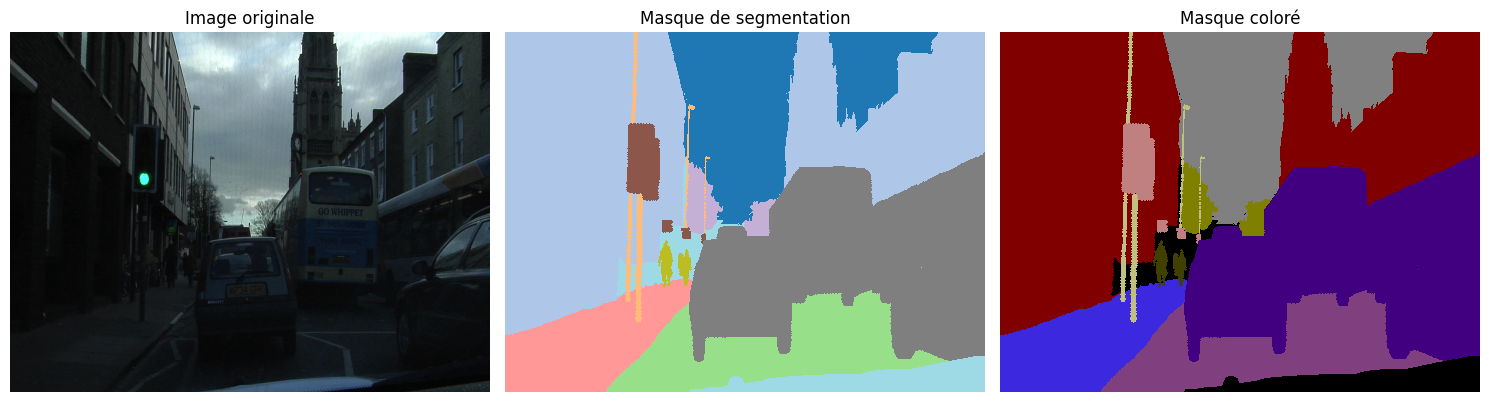

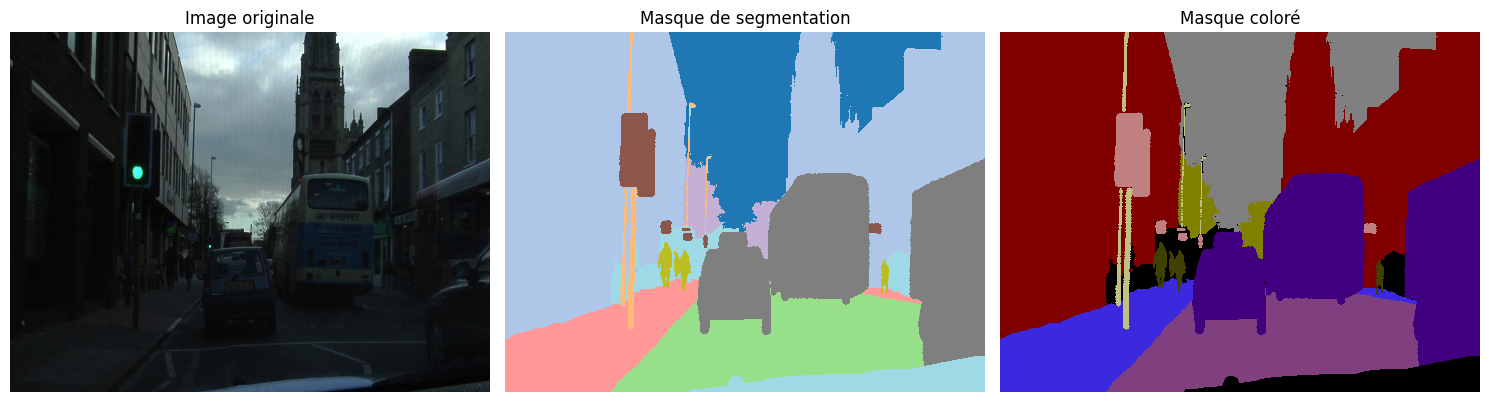

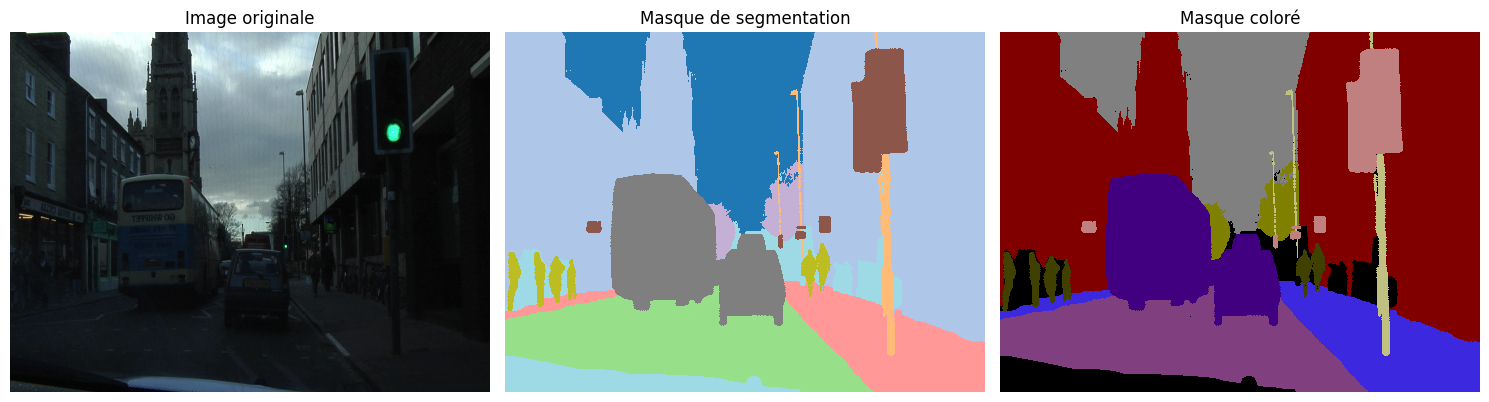

In [ ]:
def visualize_sample(dataset, idx=0):
    image, mask = dataset[idx]

    if isinstance(image, torch.Tensor):
        image = image.permute(1, 2, 0).numpy()
        mean = np.array([0.485, 0.456, 0.406])
        std = np.array([0.229, 0.224, 0.225])
        image = std * image + mean
        image = np.clip(image, 0, 1)

    if isinstance(mask, torch.Tensor):
        mask = mask.numpy()

    # Créer une version colorée du masque
    colored_mask = np.zeros((*mask.shape, 3), dtype=np.uint8)
    for class_id, color in enumerate(PALETTE):
        colored_mask[mask == class_id] = color

    # Afficher
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].imshow(image)
    axes[0].set_title('Image originale')
    axes[0].axis('off')

    axes[1].imshow(mask, cmap='tab20')
    axes[1].set_title('Masque de segmentation')
    axes[1].axis('off')

    axes[2].imshow(colored_mask)
    axes[2].set_title('Masque coloré')
    axes[2].axis('off')

    plt.tight_layout()
    plt.show()

print("\nExemples du dataset d'entraînement:")
for i in range(3):
    visualize_sample(train_dataset, idx=i)

## 8. Statistiques du Dataset

Cette section calcule les poids des classes pour aider à gérer le déséquilibre potentiel des classes dans le dataset de segmentation. Ces poids sont inversement proportionnels à la fréquence des pixels de chaque classe et peuvent être utilisés dans la fonction de perte du modèle.

In [ ]:
def compute_class_weights(dataloader, num_classes=12):
    class_counts = np.zeros(num_classes)

    for _, masks in dataloader:
        for mask in masks:
            if isinstance(mask, torch.Tensor):
                mask = mask.numpy()
            unique, counts = np.unique(mask, return_counts=True)
            for u, c in zip(unique, counts):
                if u < num_classes:
                    class_counts[int(u)] += c

    total_pixels = class_counts.sum()
    class_weights = total_pixels / (num_classes * class_counts + 1e-6)

    return torch.FloatTensor(class_weights)

class_weights = compute_class_weights(train_loader)
print("\nPoids des classes (pour gérer le déséquilibre):")
for i, weight in enumerate(class_weights):
    print(f"Classe {i}: {weight:.4f}")


Poids des classes (pour gérer le déséquilibre):
Classe 0: 0.4947
Classe 1: 0.3583
Classe 2: 8.4781
Classe 3: 0.2632
Classe 4: 1.8575
Classe 5: 0.8570
Classe 6: 7.1046
Classe 7: 7.3955
Classe 8: 1.4207
Classe 9: 13.0365
Classe 10: 28.5716
Classe 11: 2.1105


## 9. Sauvegarder la Configuration

Pour persister les résultats et la configuration du projet, cette section monte Google Drive, crée un dossier dédié si nécessaire, et sauvegarde les poids des classes calculés précédemment. Cela permet de reprendre le travail ou de réutiliser ces paramètres ultérieurement.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

project_dir = "/content/drive/MyDrive/SegFormer_UNet_Project"
os.makedirs(project_dir, exist_ok=True)

torch.save(class_weights, os.path.join(project_dir, "class_weights.pt"))

print(f"\nDataset préparé avec succès!")
print(f"Résultats sauvegardés dans: {project_dir}")

Mounted at /content/drive

Dataset préparé avec succès!
Résultats sauvegardés dans: /content/drive/MyDrive/SegFormer_UNet_Project


In [ ]:
!pip install wandb -qU
import wandb
wandb.login()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.2/27.2 MB 85.2 MB/s eta 0:00:00


/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter:

 ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: guillaumegauthier3113 (guillaumegauthier3113-polytechnique-mtl) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

## 10. Définition des Modèles (U-Net et SegFormer)

Nous allons définir deux modèles pour la segmentation sémantique : un U-Net (tel qu'initialement configuré) et un SegFormer. Cela nous permettra de comparer leurs performances. Le SegFormer est une architecture basée sur le transformeur qui combine des capacités de vision à différentes échelles pour des prédictions précises. Nous utiliserons la bibliothèque `segmentation_models_pytorch` pour instancier les deux modèles.

In [ ]:
import segmentation_models_pytorch as smp

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

model = smp.Unet(
    encoder_name="mit_b0",
    encoder_weights="imagenet",
    in_channels=3,             # RGB
    classes=len(CAMVID_CLASSES),
    activation='softmax'
).to(DEVICE)

print(f"Modèle U-Net créé avec {len(CAMVID_CLASSES)} classes et déplacé vers {DEVICE}.")

Modèle U-Net créé avec 12 classes et déplacé vers cuda.


In [ ]:
from transformers import SegformerForSemanticSegmentation, AutoImageProcessor

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

segformer_model_name = "nvidia/mit-b0"

image_processor = AutoImageProcessor.from_pretrained(segformer_model_name)

segformer_model = SegformerForSemanticSegmentation.from_pretrained(
    segformer_model_name,
    num_labels=len(CAMVID_CLASSES),
    ignore_mismatched_sizes=True
).to(DEVICE)

print(f"Modèle SegFormer ({segformer_model_name}) créé avec {len(CAMVID_CLASSES)} classes et déplacé vers {DEVICE}.")

Loading weights:   0%|          | 0/192 [00:00<?, ?it/s]

SegformerForSemanticSegmentation LOAD REPORT from: nvidia/mit-b0
Key                                           | Status     | 
----------------------------------------------+------------+-
classifier.weight                             | UNEXPECTED | 
classifier.bias                               | UNEXPECTED | 
decode_head.linear_c.{0, 1, 2, 3}.proj.weight | MISSING    | 
decode_head.classifier.weight                 | MISSING    | 
decode_head.linear_c.{0, 1, 2, 3}.proj.bias   | MISSING    | 
decode_head.batch_norm.running_var            | MISSING    | 
decode_head.batch_norm.weight                 | MISSING    | 
decode_head.batch_norm.bias                   | MISSING    | 
decode_head.batch_norm.running_mean           | MISSING    | 
decode_head.batch_norm.num_batches_tracked    | MISSING    | 
decode_head.linear_fuse.weight                | MISSING    | 
decode_head.classifier.bias                   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different ta

Modèle SegFormer (nvidia/mit-b0) créé avec 12 classes et déplacé vers cuda.


In [ ]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

params_unet = count_parameters(model)
print(f"Nombre de params - U-Net: {params_unet}")

params_segformer = count_parameters(segformer_model)
print(f"Nombre de params - SegFormer: {params_segformer}")

Nombre de params - U-Net: 5551084
Nombre de params - SegFormer: 3717228


## 11. Définition de la Fonction de Perte

Pour la segmentation sémantique, nous utiliserons une combinaison de la perte Dice et de la perte Cross-Entropy, ce qui est courant pour gérer le déséquilibre des classes et favoriser une meilleure segmentation des objets.

In [ ]:
import torch.nn as nn
import torch

class CombinedLoss(nn.Module):
    def __init__(self, dice_loss, ce_loss):
        super().__init__()
        self.dice_loss = dice_loss
        self.ce_loss = ce_loss

    def forward(self, inputs, targets):
        dice = self.dice_loss(inputs, targets)
        ce = self.ce_loss(inputs, targets)
        return dice + ce

class IoU:
    __name__ = 'iou_score'

    def __init__(self, num_classes, ignore_index=None):
        self.ignore_index = ignore_index
        self.num_classes = num_classes

    def __call__(self, outputs, labels):
        outputs = outputs.argmax(dim=1)

        # Aplatir les tenseurs
        outputs = outputs.view(-1)
        labels = labels.view(-1)

        if self.ignore_index is not None:
            # Filtrer les pixels ignorés
            valid_pixels = (labels != self.ignore_index)
            outputs = outputs[valid_pixels]
            labels = labels[valid_pixels]

        if outputs.numel() == 0:
            return 1.0

        iou_per_class = []
        for cls in range(self.num_classes):
            if cls == self.ignore_index:
                continue

            pred_mask = (outputs == cls)
            target_mask = (labels == cls)

            intersection = (pred_mask & target_mask).sum().item()
            union = (pred_mask | target_mask).sum().item()

            if union == 0:
                continue
            else:
                iou = intersection / union
                iou_per_class.append(iou)

        if len(iou_per_class) == 0:
            return 0.0

        return torch.tensor(iou_per_class).mean().item()

metrics = [
    IoU(ignore_index=11, num_classes=len(CAMVID_CLASSES))
]

## 12. Boucle d'Entraînement

Nous allons maintenant définir la boucle d'entraînement du modèle. Nous entraînerons le modèle sur les données d'entraînement et évaluerons ses performances sur l'ensemble de validation à chaque époque. Le modèle sera sauvegardé si ses performances sur l'ensemble de validation s'améliorent.

In [ ]:
from tqdm import tqdm
from torch.optim import AdamW
import torch.nn as nn
import torch.nn.functional as F
from transformers import SegformerForSemanticSegmentation

MAX_EPOCHS = 40

def train_model(model_to_train, model_name, metrics_list, train_dataloader, val_dataloader, device, max_epochs, save_dir, class_weights_tensor, learning_rate = 0.0001):
    print(f"Début de l'entraînement du modèle {model_name}...")

    optimizer = AdamW(model_to_train.parameters(), lr=learning_rate)

    dice_loss = smp.losses.DiceLoss(mode='multiclass', ignore_index=11)
    ce_loss = nn.CrossEntropyLoss(ignore_index=11, weight=class_weights_tensor.to(device))
    current_loss_fn = CombinedLoss(dice_loss, ce_loss)

    # --- Boucle d'entraînement ---
    best_iou_score = 0.0
    best_epoch = 0
    for i in range(0, max_epochs):
        print(f'\nEpoch: {i+1} ({model_name})')

        model_to_train.train()
        train_losses = []
        train_metrics = {metric.__name__: [] for metric in metrics_list}

        for images, masks in tqdm(train_dataloader, desc=f"Training Epoch {i+1} ({model_name})"):
            images = images.to(device)
            masks = masks.to(device)

            optimizer.zero_grad()

            # Gérer le format de sortie pour les modèles HuggingFace vs. SMP
            model_output = model_to_train(images)
            if hasattr(model_output, 'logits'):
                logits = model_output.logits
            else:
                logits = model_output

            # Redimensionner les masques si le modèle est SegFormer et que ses logits de sortie ont des dimensions spatiales différentes
            target_masks = masks.long()
            if isinstance(model_to_train, SegformerForSemanticSegmentation):
                target_height, target_width = logits.shape[2], logits.shape[3]
                target_masks = F.interpolate(
                    masks.unsqueeze(1).float(),
                    size=(target_height, target_width),
                    mode='nearest'
                ).squeeze(1).long()

            current_batch_loss = current_loss_fn(logits, target_masks)
            current_batch_loss.backward()
            optimizer.step()

            train_losses.append(current_batch_loss.item())
            for metric in metrics_list:
                train_metrics[metric.__name__].append(metric(logits, target_masks))

        avg_train_loss = np.mean(train_losses)
        avg_train_iou = np.mean(train_metrics['iou_score'])
        print(f"Train Loss ({model_name}): {avg_train_loss:.4f}, Train IoU ({model_name}): {avg_train_iou:.4f}")

        # --- Boucle de validation ---
        model_to_train.eval()
        valid_losses = []
        valid_metrics = {metric.__name__: [] for metric in metrics_list}

        with torch.no_grad():
            for images, masks in tqdm(val_dataloader, desc=f"Validation Epoch {i+1} ({model_name})"):
                images = images.to(device)
                masks = masks.to(device)

                # Gérer le format de sortie pour les modèles HuggingFace vs. SMP
                model_output = model_to_train(images)
                if hasattr(model_output, 'logits'):
                    logits = model_output.logits
                else:
                    logits = model_output

                # Redimensionner les masques si le modèle est SegFormer et que ses logits de sortie ont des dimensions spatiales différentes
                target_masks = masks.long()
                if isinstance(model_to_train, SegformerForSemanticSegmentation):
                    target_height, target_width = logits.shape[2], logits.shape[3]
                    target_masks = F.interpolate(
                        masks.unsqueeze(1).float(),
                        size=(target_height, target_width),
                        mode='nearest'
                    ).squeeze(1).long()

                current_batch_loss = current_loss_fn(logits, target_masks)

                valid_losses.append(current_batch_loss.item())
                for metric in metrics_list:
                    valid_metrics[metric.__name__].append(metric(logits, target_masks))

        avg_valid_loss = np.mean(valid_losses)
        avg_valid_iou = np.mean(valid_metrics['iou_score'])
        print(f"Validation Loss ({model_name}): {avg_valid_loss:.4f}, Validation IoU ({model_name}): {avg_valid_iou:.4f}")

        # Sauvegarder le meilleur modèle
        if avg_valid_iou > best_iou_score:
            best_iou_score = avg_valid_iou
            best_epoch = i + 1
            best_model_path = os.path.join(save_dir, f'best_model_{model_name}.pth')
            torch.save(model_to_train.state_dict(), best_model_path)
            print(f'Modèle {model_name} sauvegardé! IoU amélioré.')

        wandb.log(
          {
          "Train Loss": avg_train_loss,
          "Train IoU": avg_train_iou,
          "Validation Loss": avg_valid_loss,
          "Validation IoU": avg_valid_iou,
          "epoch": i + 1
          }
        )

    print(f"\nEntrainement du modèle {model_name} terminé!")
    print(f"Meilleur epoch = {best_epoch}")
    model_to_train.load_state_dict(torch.load(best_model_path, weights_only=True))

    return model_to_train

## 13. Entraînement du Modèle U-Net

In [ ]:
wandb.init(
    project="INF8225-CamVid",
    name="Unet",
    config={
        "learning_rate": 0.0001,
        "architecture": "SegFormer",
        "dataset": "CamVid",
        "epochs": 20,
    }
)

best_model_unet = train_model(
    model_to_train=model,
    model_name="UNet",
    metrics_list=metrics,
    train_dataloader=train_loader,
    val_dataloader=val_loader,
    device=DEVICE,
    max_epochs=MAX_EPOCHS,
    save_dir=project_dir,
    class_weights_tensor=class_weights
)

Début de l'entraînement du modèle UNet...

Epoch: 1 (UNet)


Training Epoch 1 (UNet):   0%|          | 0/92 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py:1776: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return self._call_impl(*args, **kwargs)
Training Epoch 1 (UNet): 100%|██████████| 92/92 [00:16<00:00,  5.75it/s]


Train Loss (UNet): 3.1482, Train IoU (UNet): 0.2051


Validation Epoch 1 (UNet): 100%|██████████| 26/26 [00:02<00:00, 10.48it/s]


Validation Loss (UNet): 3.1518, Validation IoU (UNet): 0.2802
Modèle UNet sauvegardé! IoU amélioré.

Epoch: 2 (UNet)


...

Validation Loss (UNet): 2.5178, Validation IoU (UNet): 0.6717

Epoch: 40 (UNet)


Training Epoch 40 (UNet): 100%|██████████| 92/92 [00:15<00:00,  5.86it/s]


Train Loss (UNet): 2.4589, Train IoU (UNet): 0.7162


Validation Epoch 40 (UNet): 100%|██████████| 26/26 [00:01<00:00, 15.41it/s]


Validation Loss (UNet): 2.4932, Validation IoU (UNet): 0.6904
Modèle UNet sauvegardé! IoU amélioré.

Entrainement du modèle UNet terminé!
Meilleur epoch = 40


## 14. Entraînement du Modèle SegFormer

In [ ]:
wandb.init(
    project="INF8225-CamVid",
    name="SegFormer",
    config={
        "learning_rate": 0.0001,
        "architecture": "SegFormer",
        "dataset": "CamVid",
        "epochs": 20,
    }
)

best_model_segformer = train_model(
    model_to_train=segformer_model,
    model_name="SegFormer",
    metrics_list=metrics,
    train_dataloader=train_loader,
    val_dataloader=val_loader,
    device=DEVICE,
    max_epochs=MAX_EPOCHS,
    save_dir=project_dir,
    class_weights_tensor=class_weights
)

Train IoU,▁▂▃▄▄▅▅▅▅▆▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇█████████████
Train Loss,█▆▅▅▄▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
Validation IoU,▁▂▂▄▅▅▅▅▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇▇▇▇█▇████████████
Validation Loss,█▇▇▅▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▂▁▁▁▁▁▁▁▁▂▂▁▁
epoch,▁▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇███
Train IoU,0.71621
Train Loss,2.45895
Validation IoU,0.69039
Validation Loss,2.49322
epoch,40


Début de l'entraînement du modèle SegFormer...

Epoch: 1 (SegFormer)


Training Epoch 1 (SegFormer): 100%|██████████| 92/92 [00:11<00:00,  8.27it/s]


Train Loss (SegFormer): 2.1639, Train IoU (SegFormer): 0.3545


Validation Epoch 1 (SegFormer): 100%|██████████| 26/26 [00:02<00:00, 11.32it/s]


...

Validation Loss (SegFormer): 0.5974, Validation IoU (SegFormer): 0.7100

Epoch: 40 (SegFormer)


Training Epoch 40 (SegFormer): 100%|██████████| 92/92 [00:11<00:00,  8.16it/s]


Train Loss (SegFormer): 0.3342, Train IoU (SegFormer): 0.7650


Validation Epoch 40 (SegFormer): 100%|██████████| 26/26 [00:02<00:00, 12.03it/s]


Validation Loss (SegFormer): 0.5616, Validation IoU (SegFormer): 0.7080

Entrainement du modèle SegFormer terminé!
Meilleur epoch = 37


## Évaluation des modèles

In [ ]:
import numpy as np

def calculate_iou_per_class(preds, labels, num_classes=12, ignore_index=11):
    iou_list = []

    for cls in range(num_classes):
        if cls == ignore_index:
            continue

        pred_mask = (preds == cls)
        target_mask = (labels == cls)

        intersection = (pred_mask & target_mask).sum()
        union = (pred_mask | target_mask).sum()

        if union == 0:
            iou_list.append(float('nan'))
        else:
            iou_list.append(intersection / union)

    return iou_list

def calculate_miou(iou_per_class_list):
    valid_ious = [iou for iou in iou_per_class_list if not np.isnan(iou)]
    if not valid_ious:
        return 0.0
    return np.mean(valid_ious)

import time
import torch
import torch.nn.functional as F

def evaluate_model(model, dataloader, device, num_classes=12, ignore_index=11, class_dict=CAMVID_CLASSES):
    model.eval()

    all_preds = []
    all_labels = []

    total_images = 0
    total_time = 0.0

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            labels = labels.to(device)

            total_images += images.size(0)

            if device == 'cuda': torch.cuda.synchronize()
            start_time = time.time()

            outputs = model(images)

            if device == 'cuda': torch.cuda.synchronize()
            total_time += (time.time() - start_time)

            logits = outputs.logits if hasattr(outputs, 'logits') else outputs

            # Ajustement pour SegFormer (redimensionner à la taille d'origine)
            if logits.shape[-2:] != labels.shape[-2:]:
                logits = F.interpolate(logits, size=labels.shape[-2:], mode='bilinear', align_corners=False)

            # Extraire les classes prédites et aplatir
            preds = logits.argmax(dim=1).view(-1).cpu().numpy()
            targets = labels.view(-1).cpu().numpy()

            # Garder uniquement les pixels valides (ignorer la classe 11)
            valid_mask = (targets != ignore_index)
            all_preds.append(preds[valid_mask])
            all_labels.append(targets[valid_mask])

    all_preds = np.concatenate(all_preds)
    all_labels = np.concatenate(all_labels)

    fps = total_images / total_time
    ious_per_class = calculate_iou_per_class(all_preds, all_labels, num_classes, ignore_index=-1)
    final_miou = calculate_miou(ious_per_class)

    id_to_class = {v: k for k, v in class_dict.items()}

    print(f"Vitesse d'inférence : {fps:.2f} FPS")
    print("-" * 50)
    print(f"{'CLASSE':<15} | {'IoU (%)':<10}")
    print("-" * 50)

    for cls, iou in enumerate(ious_per_class):
        if cls == ignore_index: continue
        class_name = id_to_class.get(cls, str(cls))
        if np.isnan(iou):
            print(f"{class_name:<15} | N/A")
        else:
            print(f"{class_name:<15} | {iou * 100:.2f}%")

    print("-" * 50)
    print(f"mIoU GLOBAL    | {final_miou * 100:.2f}%")
    print("=" * 50)

    return final_miou, fps

print('Évaluation du U-Net')
evaluate_model(best_model_unet, val_loader, DEVICE)

print('Évaluation du SegFormer')
evaluate_model(best_model_segformer, val_loader, DEVICE)

Évaluation du U-Net
Vitesse d'inférence : 103.62 FPS
--------------------------------------------------
CLASSE          | IoU (%)   
--------------------------------------------------
Sky             | 93.98%
Building        | 84.70%
Pole            | 16.93%
Road            | 95.50%
Pavement        | 83.64%
Tree            | 91.41%
SignSymbol      | 41.13%
Fence           | 71.68%
Car             | 84.14%
Pedestrian      | 45.96%
Bicyclist       | 71.06%
--------------------------------------------------
mIoU GLOBAL    | 70.92%
Évaluation du SegFormer
Vitesse d'inférence : 122.96 FPS
--------------------------------------------------
CLASSE          | IoU (%)   
--------------------------------------------------
Sky             | 93.29%
Building        | 87.87%
Pole            | 17.88%
Road            | 94.93%
Pavement        | 82.15%
Tree            | 91.16%
SignSymbol      | 50.66%
Fence           | 69.22%
Car             | 83.41%
Pedestrian      | 53.04%
Bicyclist       | 73.13%
---

(np.float64(0.7243048432833743), 122.96245132657312)


Résultats pour le U-Net :


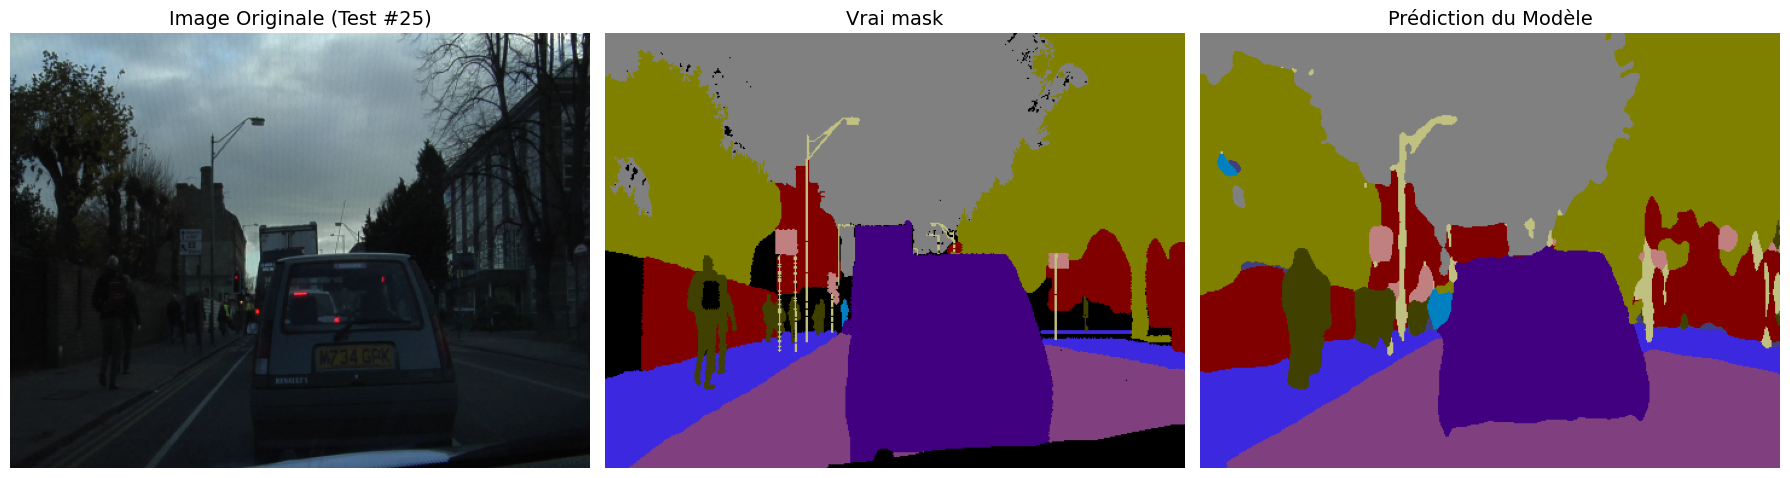

Résultats pour le SegFormer :


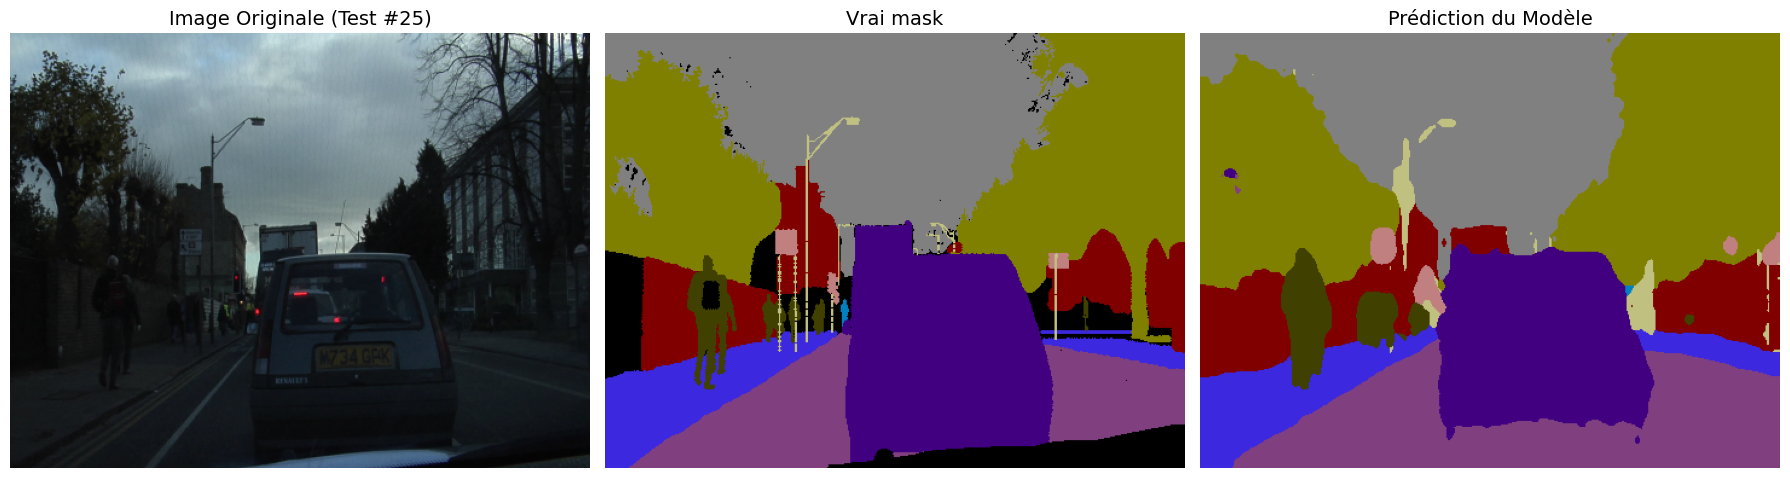

In [ ]:
import torch.nn.functional as F
import numpy as np

def visualize_prediction(model, dataset, idx, device, palette):
    model.eval()

    image_tensor, mask_truth = dataset[idx]

    image_display = image_tensor.permute(1, 2, 0).cpu().numpy()
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    image_display = std * image_display + mean
    image_display = np.clip(image_display, 0, 1)

    with torch.no_grad():
        img_input = image_tensor.unsqueeze(0).to(device)
        output = model(img_input)

        logits = output.logits if hasattr(output, 'logits') else output

        if logits.shape[-2:] != mask_truth.shape:
            logits = F.interpolate(logits, size=mask_truth.shape, mode='bilinear', align_corners=False)

        pred_mask = logits.argmax(dim=1).squeeze(0).cpu().numpy()

    if isinstance(mask_truth, torch.Tensor):
        mask_truth = mask_truth.numpy()

    def colorize_mask(mask_2d):
        colored = np.zeros((*mask_2d.shape, 3), dtype=np.uint8)
        for class_id, color in enumerate(palette):
            colored[mask_2d == class_id] = color
        return colored

    truth_colored = colorize_mask(mask_truth)
    pred_colored = colorize_mask(pred_mask)

    # Affichage
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    axes[0].imshow(image_display)
    axes[0].set_title(f'Image Originale (Test #{idx})', fontsize=14)
    axes[0].axis('off')

    axes[1].imshow(truth_colored)
    axes[1].set_title('Masque réel', fontsize=14)
    axes[1].axis('off')

    axes[2].imshow(pred_colored)
    axes[2].set_title(f'Prédiction du Modèle', fontsize=14)
    axes[2].axis('off')

    plt.tight_layout()
    plt.show()

index_image = 25

print("\nRésultats pour le U-Net :")
visualize_prediction(best_model_unet, test_dataset, idx=index_image, device=DEVICE, palette=PALETTE)

print("Résultats pour le SegFormer :")
visualize_prediction(best_model_segformer, test_dataset, idx=index_image, device=DEVICE, palette=PALETTE)